## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.linear_model import LinearRegression
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 2. Data Loading

In [2]:
data_LGD = pd.read_excel(r'D:\New folder (3)\Orxan\Python\datasocool\lgd_data.xlsx')

In [3]:
data_LGD.head(3)

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,LGD%
0,238203,729,36,3.81,47603,88,24,4,2,Rent,Home Improvement,Adjustable Rate,South,0.010000
1,170008,745,36,6.68,67474,71,43,4,2,Mortgage,Auto Loan,Adjustable Rate,South,0.757182
2,198937,681,24,8.38,77036,74,46,6,1,Own,Personal Loan,Fixed Rate,West,0.575147


## 3. Exploratory Data Analysis (EDA)

In [4]:
data_LGD.describe(include = 'all')

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,LGD%
count,40000.000000,40000.000000,40000.00000,40000.000000,40000.000000,40000.000000,40000.00000,40000.000000,40000.000000,40000,40000,40000,40000,40000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,5,2,4,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rent,Auto Loan,Adjustable Rate,North,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13420,8163,20161,10165,NaN
mean,149811.070400,700.667300,47.91060,6.499560,60069.306750,79.982225,30.08045,5.002275,0.998925,NaN,NaN,NaN,NaN,0.320288
std,49836.964295,49.974161,17.00847,1.504729,19926.497499,9.986641,9.98215,2.015557,0.818530,NaN,NaN,NaN,NaN,0.341183
min,-82998.000000,505.000000,24.00000,0.380000,-17513.000000,37.000000,-13.00000,-5.000000,0.000000,NaN,NaN,NaN,NaN,0.009717
25%,116398.000000,667.000000,36.00000,5.480000,46567.500000,73.000000,23.00000,4.000000,0.000000,NaN,NaN,NaN,NaN,0.010001
50%,149822.500000,701.000000,48.00000,6.490000,60058.000000,80.000000,30.00000,5.000000,1.000000,NaN,NaN,NaN,NaN,0.197368
75%,183328.000000,734.000000,60.00000,7.520000,73416.750000,87.000000,37.00000,6.000000,2.000000,NaN,NaN,NaN,NaN,0.572629


## 4. Missing Value Analysis

In [5]:
data_LGD.isna().sum()

Exposure Amount ($)           0
Credit Score                  0
Loan Term (Months)            0
Interest Rate (%)             0
Income ($)                    0
Loan to Value Ratio (%)       0
Debt to Income Ratio (%)      0
Employment History (Years)    0
Previous Defaults             0
Home Ownership                0
Loan Purpose                  0
Loan Type                     0
Region                        0
LGD%                          0
dtype: int64

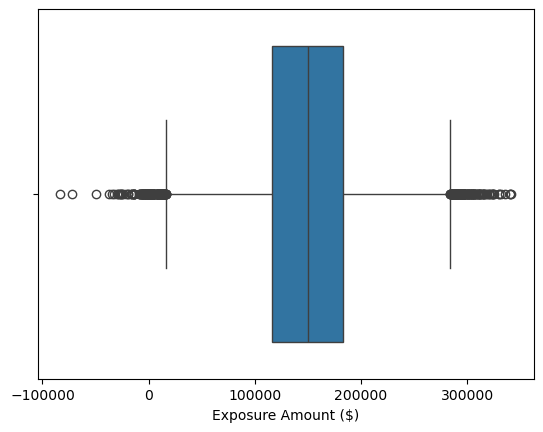

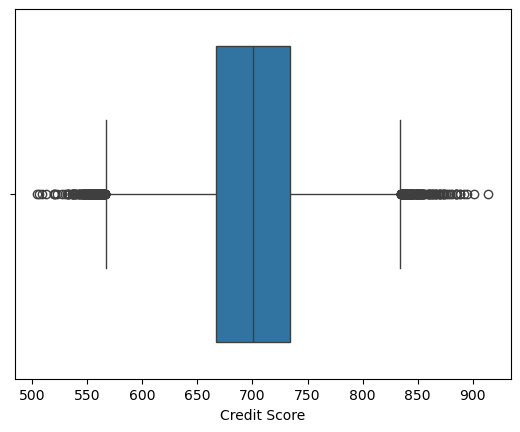

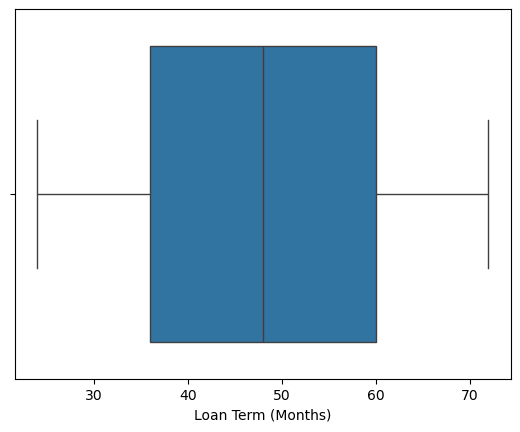

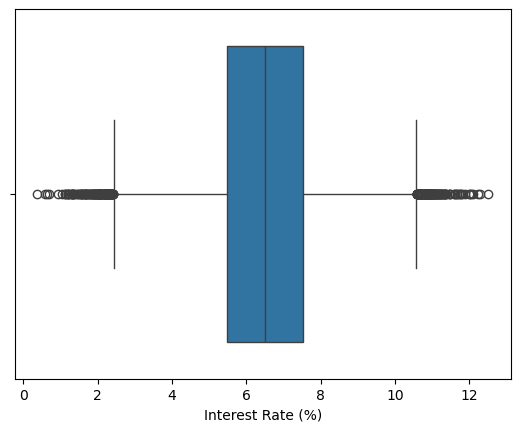

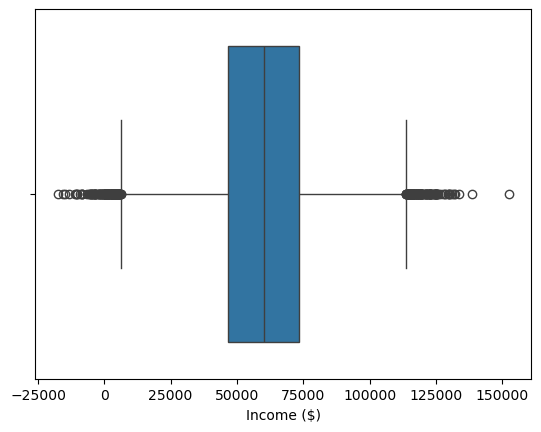

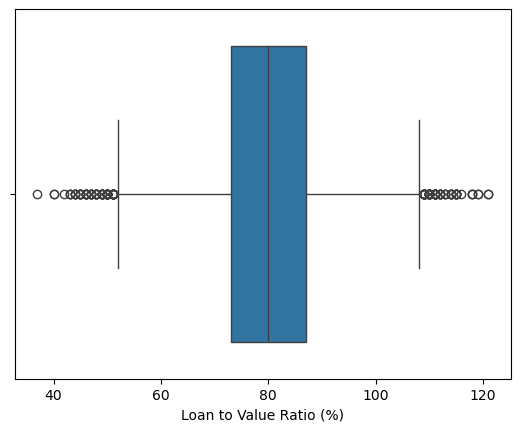

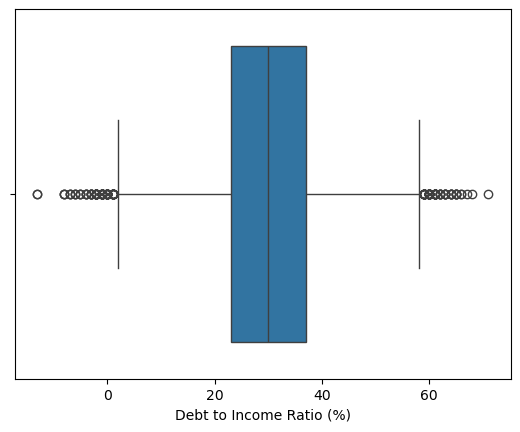

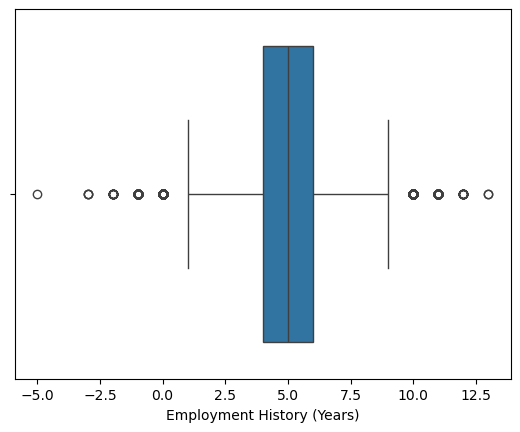

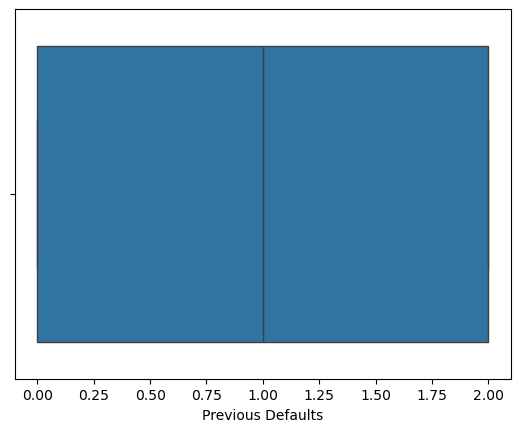

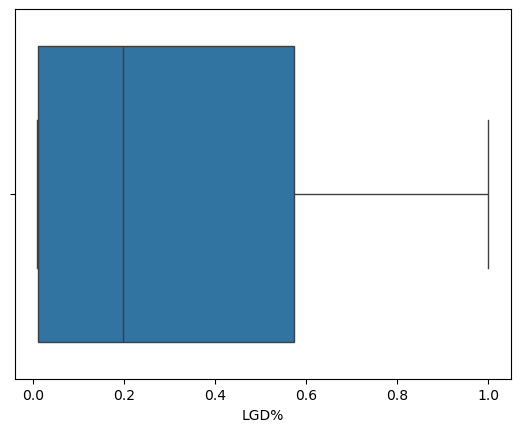

In [7]:
for i in data_LGD.columns:
    if data_LGD[i].dtypes!=object:
        sns.boxplot(data=data_LGD,x=data_LGD[i])
        plt.show()

## 5. Outlier treatment

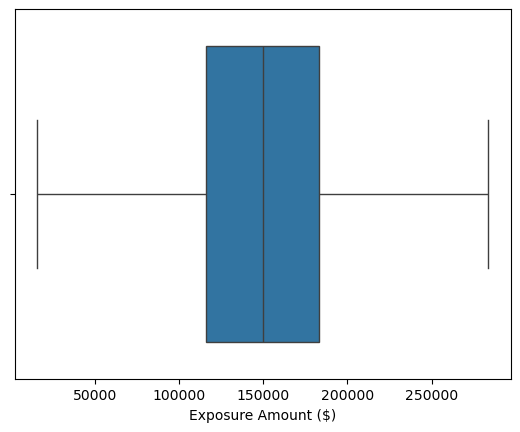

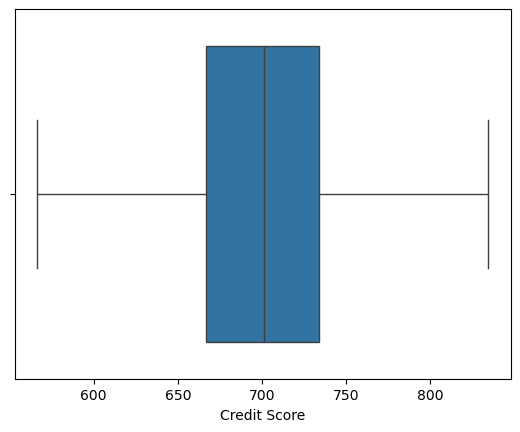

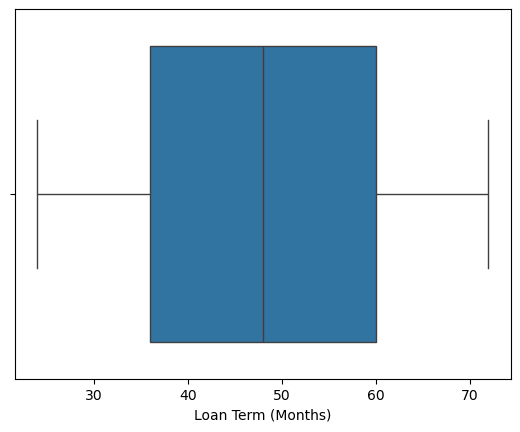

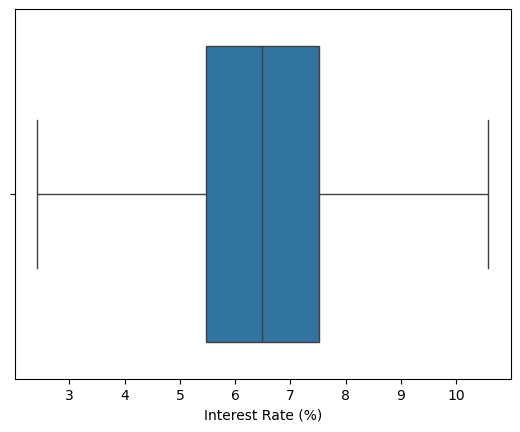

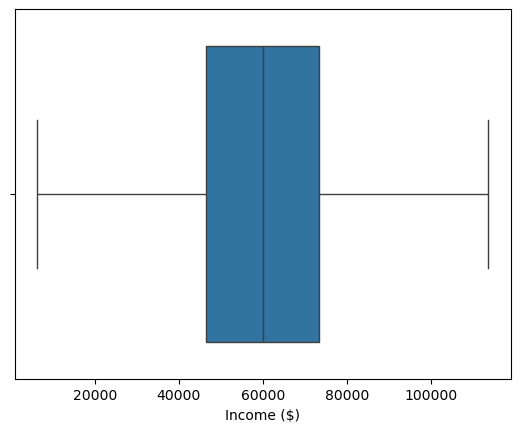

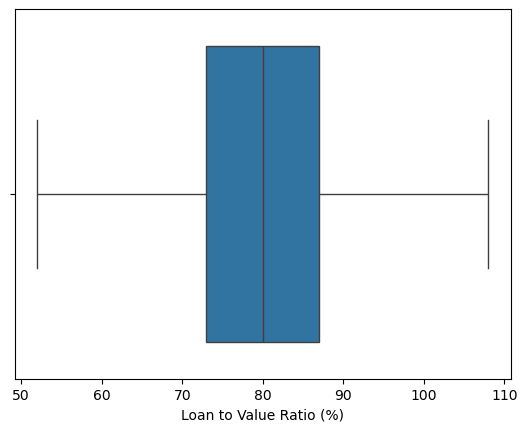

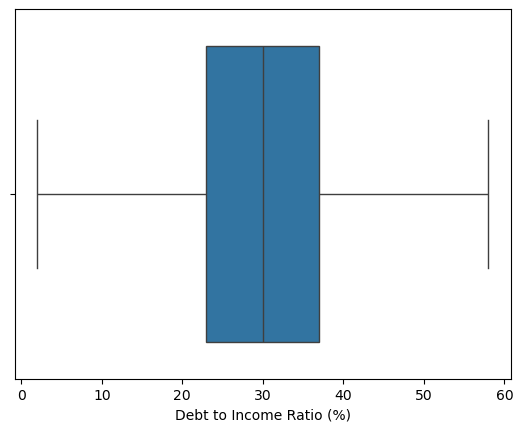

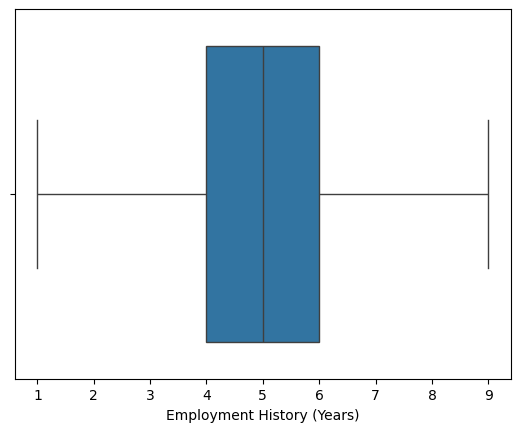

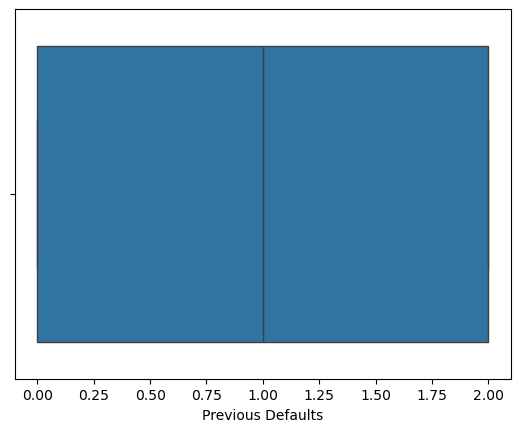

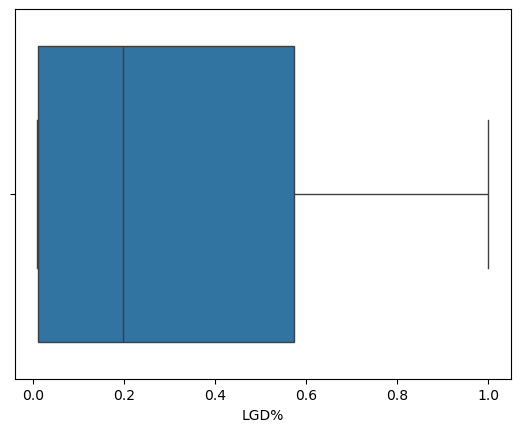

In [8]:
q1 = data_LGD.quantile(0.25, numeric_only=True)
q3 = data_LGD.quantile(0.75, numeric_only=True)
IQR = q3-q1

Lower = q1 - 1.5 * IQR
Upper = q3 + 1.5 * IQR

for i in data_LGD.columns:
    if data_LGD[i].dtypes != object:
        data_LGD[i] = np.where(data_LGD[i] > Upper[i],Upper[i],data_LGD[i])
        data_LGD[i] = np.where(data_LGD[i] < Lower[i],Lower[i],data_LGD[i])
        sns.boxplot(data=data_LGD,x=data_LGD[i])
        plt.show()

# 6. Feature Engineering

In [9]:
data_LGD['Income_mean_by_Region'] = data_LGD.groupby('Region')['Income ($)'].transform('mean')
data_LGD['Previous_Defaults_mean_by_Credit_Score'] = data_LGD.groupby('Credit Score')['Previous Defaults'].transform('mean')

In [10]:
data_LGD.head(3)

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,LGD%,Income_mean_by_Region,Previous_Defaults_mean_by_Credit_Score
0,238203.0,729.0,36.0,3.81,47603.0,88.0,24.0,4.0,2.0,Rent,Home Improvement,Adjustable Rate,South,0.010000,60082.674340,0.938525
1,170008.0,745.0,36.0,6.68,67474.0,71.0,43.0,4.0,2.0,Mortgage,Auto Loan,Adjustable Rate,South,0.757182,60082.674340,1.022321
2,198937.0,681.0,24.0,8.38,77036.0,74.0,46.0,6.0,1.0,Own,Personal Loan,Fixed Rate,West,0.575147,60307.337702,1.030303


In [11]:
for i in data_LGD.columns[-2:]:
    print(data_LGD[i].value_counts())

Income_mean_by_Region
59985.178837    10165
60307.337702    10024
60082.674340     9959
59894.065761     9852
Name: count, dtype: int64
Previous_Defaults_mean_by_Credit_Score
1.000000    1453
1.030303     528
0.953488     430
1.008721     344
0.959184     343
            ... 
1.300000      10
1.200000      10
1.333333       9
1.222222       9
0.625000       8
Name: count, Length: 234, dtype: int64


## 7. Distribution Analysis (Normality Testing)



In [12]:
for i in data_LGD.columns:    
    if data_LGD[i].dtype in ['int64', 'float64']:
        kstest_statistic, kstest_p_value = stats.kstest(data_LGD[i], 'norm')
        print(i)
        print('p-value:', kstest_p_value)
        if kstest_p_value > 0.05:
            print('normally distributed')
            print()
        else:
            print('not normally distributed')
            print()

Exposure Amount ($)
p-value: 0.0
not normally distributed

Credit Score
p-value: 0.0
not normally distributed

Loan Term (Months)
p-value: 0.0
not normally distributed

Interest Rate (%)
p-value: 0.0
not normally distributed

Income ($)
p-value: 0.0
not normally distributed

Loan to Value Ratio (%)
p-value: 0.0
not normally distributed

Debt to Income Ratio (%)
p-value: 0.0
not normally distributed

Employment History (Years)
p-value: 0.0
not normally distributed

Previous Defaults
p-value: 0.0
not normally distributed

LGD%
p-value: 0.0
not normally distributed

Income_mean_by_Region
p-value: 0.0
not normally distributed

Previous_Defaults_mean_by_Credit_Score
p-value: 0.0
not normally distributed



## 8. Correlation Analysis & Feature Selection

#### Thresholds 
1. target 10%
2. intercorrelation 60%

In [13]:
data_LGD.corr(numeric_only = True, method = 'spearman') #NOT normal distrubuted

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,LGD%,Income_mean_by_Region,Previous_Defaults_mean_by_Credit_Score
Exposure Amount ($),1.000000,0.000537,-0.004889,0.007016,-0.001408,0.001700,0.001135,0.001011,0.003210,0.108719,0.000093,0.002993
Credit Score,0.000537,1.000000,0.005094,0.002438,0.003012,0.003004,-0.005423,0.002966,0.003455,0.489755,0.001896,0.010395
Loan Term (Months),-0.004889,0.005094,1.000000,-0.005708,-0.000408,0.000966,-0.002118,0.000815,-0.002210,0.337089,-0.005692,-0.004345
Interest Rate (%),0.007016,0.002438,-0.005708,1.000000,0.001770,0.000017,-0.000638,0.004275,0.003819,0.165559,-0.000407,0.002013
Income ($),-0.001408,0.003012,-0.000408,0.001770,1.000000,-0.008877,0.010637,-0.004133,-0.000187,0.405091,0.007087,0.000476
Loan to Value Ratio (%),0.001700,0.003004,0.000966,0.000017,-0.008877,1.000000,-0.000482,-0.003582,-0.000311,0.240004,0.003880,-0.008032
Debt to Income Ratio (%),0.001135,-0.005423,-0.002118,-0.000638,0.010637,-0.000482,1.000000,-0.001078,-0.003350,0.319163,0.002722,0.000826
Employment History (Years),0.001011,0.002966,0.000815,0.004275,-0.004133,-0.003582,-0.001078,1.000000,0.004300,0.160256,0.002791,-0.003018
Previous Defaults,0.003210,0.003455,-0.002210,0.003819,-0.000187,-0.000311,-0.003350,0.004300,1.000000,0.253319,-0.000845,0.076758
LGD%,0.108719,0.489755,0.337089,0.165559,0.405091,0.240004,0.319163,0.160256,0.253319,1.000000,0.005827,0.028162


In [14]:
def target_correlation(data_LGD, target, threshold = 0.1):
    corr = data_LGD.corr(numeric_only = True, method = 'spearman')[target].drop(target)
    corr = corr[corr.abs() >= threshold]
    corr = corr.reindex(corr.abs().sort_values(ascending = False).index)
    return corr.reset_index().rename(columns={"index": "Variable", target: "Correlation with Target"})


In [15]:
target_result = target_correlation(data_LGD, 'LGD%')

target_result

,Variable,Correlation with Target
0,Credit Score,0.489755
1,Income ($),0.405091
2,Loan Term (Months),0.337089
3,Debt to Income Ratio (%),0.319163
4,Previous Defaults,0.253319
5,Loan to Value Ratio (%),0.240004
6,Interest Rate (%),0.165559
7,Employment History (Years),0.160256
8,Exposure Amount ($),0.108719


In [16]:
def intercorrelation(data_LGD, inter, threshold = 0.6): 
    corr_matrix = data_LGD.drop(columns = [inter]).corr(numeric_only = True, method = 'spearman')
    mask = np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool)
    high_corr = corr_matrix.where(mask).stack().reset_index()
    high_corr.columns = ["Variable 1", "Variable 2", "Correlation"]
    high_corr = high_corr[high_corr["Correlation"].abs() >= threshold]
    return high_corr.reset_index(drop=True)
    

In [17]:
intercorrelated_result = intercorrelation(data_LGD, 'LGD%')
intercorrelated_result

,Variable 1,Variable 2,Correlation


## 9. Multicollinearity Check (VIF)

In [18]:
def calculate_vif(data, variables):
    vif_data = data[variables]
    vif_values = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
    vif_result = pd.DataFrame({'VIF': vif_values, 'Features': variables})
    return vif_result


vif_result = calculate_vif(data_LGD, [
                                                #'Credit Score',
                                                'Income ($)',
                                                'Loan Term (Months)',
                                                'Debt to Income Ratio (%)',
                                                'Previous Defaults',
                                                #'Loan to Value Ratio (%)',
                                                #'Interest Rate (%)',
                                                'Employment History (Years)',
                                                'Exposure Amount ($)'
                                        ])

vif_result

,VIF,Features
0,8.120835,Income ($)
1,7.324425,Loan Term (Months)
2,8.116730,Debt to Income Ratio (%)
3,2.405987,Previous Defaults
4,6.504986,Employment History (Years)
5,8.070681,Exposure Amount ($)


# 10. Feature Selection

In [19]:
data_LGD_dropped = data_LGD.drop(['Credit Score','Loan to Value Ratio (%)','Interest Rate (%)'], axis=1)


In [20]:
data_LGD_dropped.head(3)

,Exposure Amount ($),Loan Term (Months),Income ($),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,LGD%,Income_mean_by_Region,Previous_Defaults_mean_by_Credit_Score
0,238203.0,36.0,47603.0,24.0,4.0,2.0,Rent,Home Improvement,Adjustable Rate,South,0.010000,60082.674340,0.938525
1,170008.0,36.0,67474.0,43.0,4.0,2.0,Mortgage,Auto Loan,Adjustable Rate,South,0.757182,60082.674340,1.022321
2,198937.0,24.0,77036.0,46.0,6.0,1.0,Own,Personal Loan,Fixed Rate,West,0.575147,60307.337702,1.030303


## 11. Categorical Encoding (One-Hot Encoding)

In [21]:
data_LGD_dropped_dummy = pd.get_dummies(data_LGD_dropped, drop_first=True, dtype=int)

data_LGD_dropped_dummy.head(3)

,Exposure Amount ($),Loan Term (Months),Income ($),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,LGD%,Income_mean_by_Region,Previous_Defaults_mean_by_Credit_Score,Home Ownership_Own,Home Ownership_Rent,Loan Purpose_Debt Consolidation,Loan Purpose_Home Improvement,Loan Purpose_Home Purchase,Loan Purpose_Personal Loan,Loan Type_Fixed Rate,Region_North,Region_South,Region_West
0,238203.0,36.0,47603.0,24.0,4.0,2.0,0.010000,60082.674340,0.938525,0,1,0,1,0,0,0,0,1,0
1,170008.0,36.0,67474.0,43.0,4.0,2.0,0.757182,60082.674340,1.022321,0,0,0,0,0,0,0,0,1,0
2,198937.0,24.0,77036.0,46.0,6.0,1.0,0.575147,60307.337702,1.030303,1,0,0,0,0,1,1,0,0,1


## 12. Train/Test Feature-Target Split

In [22]:
targets = data_LGD_dropped_dummy['LGD%']

inputs = data_LGD_dropped_dummy.drop(['LGD%'],axis=1)

## 13. Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(inputs) 

,copy,True
,with_mean,True
,with_std,True


In [24]:
inputs_scaled = scaler.transform(inputs)

data_scaled = pd.DataFrame(inputs_scaled, columns=inputs.columns)

data_scaled

,Exposure Amount ($),Loan Term (Months),Income ($),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Income_mean_by_Region,Previous_Defaults_mean_by_Credit_Score,Home Ownership_Own,Home Ownership_Rent,Loan Purpose_Debt Consolidation,Loan Purpose_Home Improvement,Loan Purpose_Home Purchase,Loan Purpose_Personal Loan,Loan Type_Fixed Rate,Region_North,Region_South,Region_West
0,1.786404,-0.700283,-0.629277,-0.612479,-0.517597,1.223032,0.097178,-0.869497,-0.709601,1.407347,-0.501484,1.988973,-0.493154,-0.496208,-0.991982,-0.583701,1.736798,-0.578274
1,0.408114,-0.700283,0.373902,1.300527,-0.517597,1.223032,0.097178,0.336804,-0.709601,-0.710557,-0.501484,-0.502772,-0.493154,-0.496208,-0.991982,-0.583701,1.736798,-0.578274
2,0.992798,-1.405823,0.856635,1.602580,0.513114,0.001313,1.559518,0.451704,1.409243,-0.710557,-0.501484,-0.502772,-0.493154,2.015284,1.008083,-0.583701,-0.575772,1.729284
3,2.268275,0.005256,-0.251653,-0.612479,-2.063665,-1.220405,1.559518,-0.187995,-0.709601,-0.710557,-0.501484,-0.502772,2.027763,-0.496208,-0.991982,-0.583701,-0.575772,1.729284
4,1.890996,1.416336,0.508897,0.998473,-0.002242,-1.220405,-0.537423,0.685036,-0.709601,-0.710557,1.994082,-0.502772,-0.493154,-0.496208,1.008083,1.713205,-0.575772,-0.578274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,-1.468843,-1.405823,0.577910,-1.317271,-1.032953,-1.220405,-0.537423,-0.180383,-0.709601,-0.710557,1.994082,-0.502772,-0.493154,-0.496208,-0.991982,1.713205,-0.575772,-0.578274
39996,2.036071,1.416336,-0.744231,0.394366,-1.032953,-1.220405,1.559518,0.495327,-0.709601,1.407347,-0.501484,-0.502772,-0.493154,-0.496208,1.008083,-0.583701,-0.575772,1.729284
39997,1.711421,0.710796,-0.588132,-0.612479,1.028470,0.001313,1.559518,0.015475,-0.709601,1.407347,1.994082,-0.502772,-0.493154,-0.496208,1.008083,-0.583701,-0.575772,1.729284
39998,0.205801,-0.700283,1.308522,0.696420,0.513114,-1.220405,1.559518,-0.515904,-0.709601,-0.710557,-0.501484,-0.502772,-0.493154,2.015284,-0.991982,-0.583701,-0.575772,1.729284


## 14. Train-Test split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_scaled, targets, test_size=0.2, random_state=42)

## 15. Linear Regression Model

In [26]:
reg = LinearRegression()

reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 16. Prediction and Model Performance

In [27]:
y_pred = reg.predict(X_test)
y_pred_train = reg.predict(X_train)

In [28]:
from sklearn import metrics

mae_test = metrics.mean_absolute_error(y_test, y_pred)
mse_test = metrics.mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = metrics.r2_score(y_test, y_pred)

mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
mse_train = metrics.mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = metrics.r2_score(y_train, y_pred_train)

def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

n_train = len(y_train)
n_test = len(y_test)
k = X_train.shape[1]

adj_r2_train = adjusted_r2(r2_train, n_train, k)
adj_r2_test = adjusted_r2(r2_test, n_test, k)

# Results summary
results_dict = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2', 'Adjusted R2'],
    'Train': [mae_train, mse_train, rmse_train, r2_train, adj_r2_train],
    'Test': [mae_test, mse_test, rmse_test, r2_test, adj_r2_test]
}

results_df = pd.DataFrame(results_dict)

results_df

,Metric,Train,Test
0,MAE,0.196817,0.198745
1,MSE,0.059049,0.060065
2,RMSE,0.243000,0.245081
3,R2,0.493463,0.480899
4,Adjusted R2,0.493177,0.479728


## 17. Univariate analysis

In [29]:
results = []

for i in X_train.columns: 
    X_train_single_var = X_train[[i]]
    X_test_single_var = X_test[[i]]
    reg.fit(X_train_single_var, y_train)
    y_pred_train_single_var = reg.predict(X_train_single_var)
    train_r2 = metrics.r2_score(y_train, y_pred_train_single_var)
    y_pred_test_single_var = reg.predict(X_test_single_var)
    test_r2 = metrics.r2_score(y_test, y_pred_test_single_var)
    results.append({'Variable': i, 'Train R2': train_r2, 'Test R2': test_r2})

results_df = pd.DataFrame(results)

results_df_sorted = results_df.sort_values(by='Test R2', ascending=False)

results_df_sorted

,Variable,Train R2,Test R2
2,Income ($),1.731096e-01,0.159929
1,Loan Term (Months),1.101374e-01,0.113298
3,Debt to Income Ratio (%),1.081936e-01,0.101993
5,Previous Defaults,6.345464e-02,0.064793
4,Employment History (Years),2.556484e-02,0.031549
0,Exposure Amount ($),1.332307e-02,0.010389
7,Previous_Defaults_mean_by_Credit_Score,2.089689e-03,0.002181
17,Region_West,3.970387e-05,-0.000053
14,Loan Type_Fixed Rate,1.914607e-06,-0.000085
12,Loan Purpose_Home Purchase,6.104503e-07,-0.000103


## 18. Model Refinement with Selected Features

In [30]:
powerful_inputs = data_scaled[['Income ($)', 'Loan Term (Months)','Debt to Income Ratio (%)',
                               'Previous Defaults','Employment History (Years)','Exposure Amount ($)']]


In [31]:
from sklearn.model_selection import train_test_split

X_train_uni, X_test_uni, y_train_uni, y_test_uni = train_test_split(powerful_inputs, targets, test_size=0.2, random_state=42)


In [32]:
reg = LinearRegression()
reg.fit(X_train_uni,y_train_uni)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pred_uni = reg.predict(X_test_uni)
y_pred_train_uni = reg.predict(X_train_uni)

In [34]:
mae_test = metrics.mean_absolute_error(y_test_uni, y_pred_uni)
mse_test = metrics.mean_squared_error(y_test_uni, y_pred_uni)
rmse_test = np.sqrt(mse_test)
r2_test = metrics.r2_score(y_test_uni, y_pred_uni)

mae_train = metrics.mean_absolute_error(y_train_uni, y_pred_train_uni)
mse_train = metrics.mean_squared_error(y_train_uni, y_pred_train_uni)
rmse_train = np.sqrt(mse_train)
r2_train = metrics.r2_score(y_train_uni, y_pred_train_uni)

def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

n_train = len(y_train_uni)
n_test = len(y_test_uni)
k = X_train_uni.shape[1]

adj_r2_train = adjusted_r2(r2_train, n_train, k)
adj_r2_test = adjusted_r2(r2_test, n_test, k)


# Results summary
results_dict = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2', 'Adjusted R2'],
    'Train': [mae_train, mse_train, rmse_train, r2_train, adj_r2_train],
    'Test': [mae_test, mse_test, rmse_test, r2_test, adj_r2_test]
}

results_df = pd.DataFrame(results_dict)

results_df

,Metric,Train,Test
0,MAE,0.196889,0.198746
1,MSE,0.059135,0.060069
2,RMSE,0.243178,0.245090
3,R2,0.492722,0.480858
4,Adjusted R2,0.492627,0.480469


# 19. Model Deployment & Prediction

In [36]:
deploy = pd.read_excel(r'D:\New folder (3)\Orxan\Python\datasocool\lgd_data_deploy.xlsx')

In [37]:
deploy.head(3)

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region
0,153539,715,36,6.85,57712,92,23,6,1,Mortgage,Home Improvement,Adjustable Rate,West
1,137842,713,36,6.65,37490,83,41,7,0,Mortgage,Debt Consolidation,Fixed Rate,East
2,187289,606,72,5.00,35857,79,46,7,1,Mortgage,Home Improvement,Adjustable Rate,East


In [38]:
deploy.isna().sum()

Exposure Amount ($)           0
Credit Score                  0
Loan Term (Months)            0
Interest Rate (%)             0
Income ($)                    0
Loan to Value Ratio (%)       0
Debt to Income Ratio (%)      0
Employment History (Years)    0
Previous Defaults             0
Home Ownership                0
Loan Purpose                  0
Loan Type                     0
Region                        0
dtype: int64

In [ ]:
q1 = deploy.quantile(0.25, numeric_only=True)
q3 = deploy.quantile(0.75, numeric_only=True)
IQR = q3-q1

Lower = q1 - 1.5 * IQR
Upper = q3 + 1.5 * IQR

for i in deploy.columns:
    if deploy[i].dtypes != object:
        deploy[i] = np.where(deploy[i] > Upper[i],Upper[i],deploy[i])
        deploy[i] = np.where(deploy[i] < Lower[i],Lower[i],deploy[i])
        sns.boxplot(data=deploy,x=deploy[i])
        plt.show()

In [42]:
deploy['Income_mean_by_Region'] = deploy.groupby('Region')['Income ($)'].transform('mean')
deploy['Previous_Defaults_mean_by_Credit_Score'] = deploy.groupby('Credit Score')['Previous Defaults'].transform('mean')

In [61]:
powerful_inputs_deploy = deploy[['Income ($)', 'Loan Term (Months)','Debt to Income Ratio (%)',
                               'Previous Defaults','Employment History (Years)','Exposure Amount ($)']]

powerful_inputs_deploy.head(3)


,Income ($),Loan Term (Months),Debt to Income Ratio (%),Previous Defaults,Employment History (Years),Exposure Amount ($)
0,57712.0,36.0,23.0,1.0,6.0,153539.0
1,37490.0,36.0,41.0,0.0,7.0,137842.0
2,35857.0,72.0,46.0,1.0,7.0,187289.0


In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(powerful_inputs_deploy) 

,copy,True
,with_mean,True
,with_std,True


In [69]:
inputs_scaled_deploy = scaler.transform(powerful_inputs_deploy)

data_scaled_deploy = pd.DataFrame(inputs_scaled_deploy, columns=powerful_inputs_deploy.columns)

data_scaled_deploy.head(3)

,Income ($),Loan Term (Months),Debt to Income Ratio (%),Previous Defaults,Employment History (Years),Exposure Amount ($)
0,-0.092451,-0.693375,-0.722497,0.057477,0.538122,0.072405
1,-1.153920,-0.693375,1.163303,-1.219781,1.059306,-0.262017
2,-1.239638,1.386750,1.687137,0.057477,1.059306,0.791442


In [70]:
data_scaled_deploy['predicted_LGD'] = reg.predict(data_scaled_deploy)

data_scaled_deploy

,Income ($),Loan Term (Months),Debt to Income Ratio (%),Previous Defaults,Employment History (Years),Exposure Amount ($),predicted_LGD
0,-0.092451,-0.693375,-0.722497,0.057477,0.538122,0.072405,0.186034
1,-1.153920,-0.693375,1.163303,-1.219781,1.059306,-0.262017,0.152092
2,-1.239638,1.386750,1.687137,0.057477,1.059306,0.791442,0.586777
3,-1.151768,1.386750,-1.036797,1.334735,-0.504245,-1.109758,0.245497
4,1.334250,-0.693375,-0.198664,-1.219781,-1.546613,-0.627821,0.191305
...,...,...,...,...,...,...,...
395,0.361385,-1.386750,-0.722497,0.057477,-0.504245,-1.414651,0.055007
396,0.653287,-0.693375,0.849003,0.057477,0.016938,-0.450288,0.416492
397,-1.617047,1.386750,1.268070,-1.219781,-0.504245,-0.434054,0.241858
398,-0.188351,-1.386750,0.849003,-1.219781,0.016938,0.979095,0.164082
